<a href="https://colab.research.google.com/github/subramanyaj-cs23/diabetes-detection/blob/main/metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading dataset from: data.csv
Train shape: (12923, 7), Test shape: (8616, 7)
Resampled train shape after SMOTE: (12964, 7)

Evaluating Model: Decision Tree
Cross-validation scores: [0.90165831 0.90358658 0.90050135 0.89895874 0.90432099]
Mean CV Accuracy: 0.9018
CV Accuracy Std Dev (Fold Variability): 0.0020
Test Accuracy: 0.9067
95% Confidence Interval for Test Accuracy: [0.9008, 0.9128]

Classification Report (including Precision, Sensitivity/Recall, F1):
                  precision    recall  f1-score   support

     Prediabetic       1.00      1.00      1.00      2135
 Type 1 Diabetes       1.00      1.00      1.00      2209
 Type 2 Diabetes       0.73      1.00      0.84      2159
Type 3c Diabetes       1.00      0.62      0.77      2113

        accuracy                           0.91      8616
       macro avg       0.93      0.90      0.90      8616
    weighted avg       0.93      0.91      0.90      8616


Sensitivity (Recall) per class:
  Prediabetic: 1.0000
  Type 1 Diabet

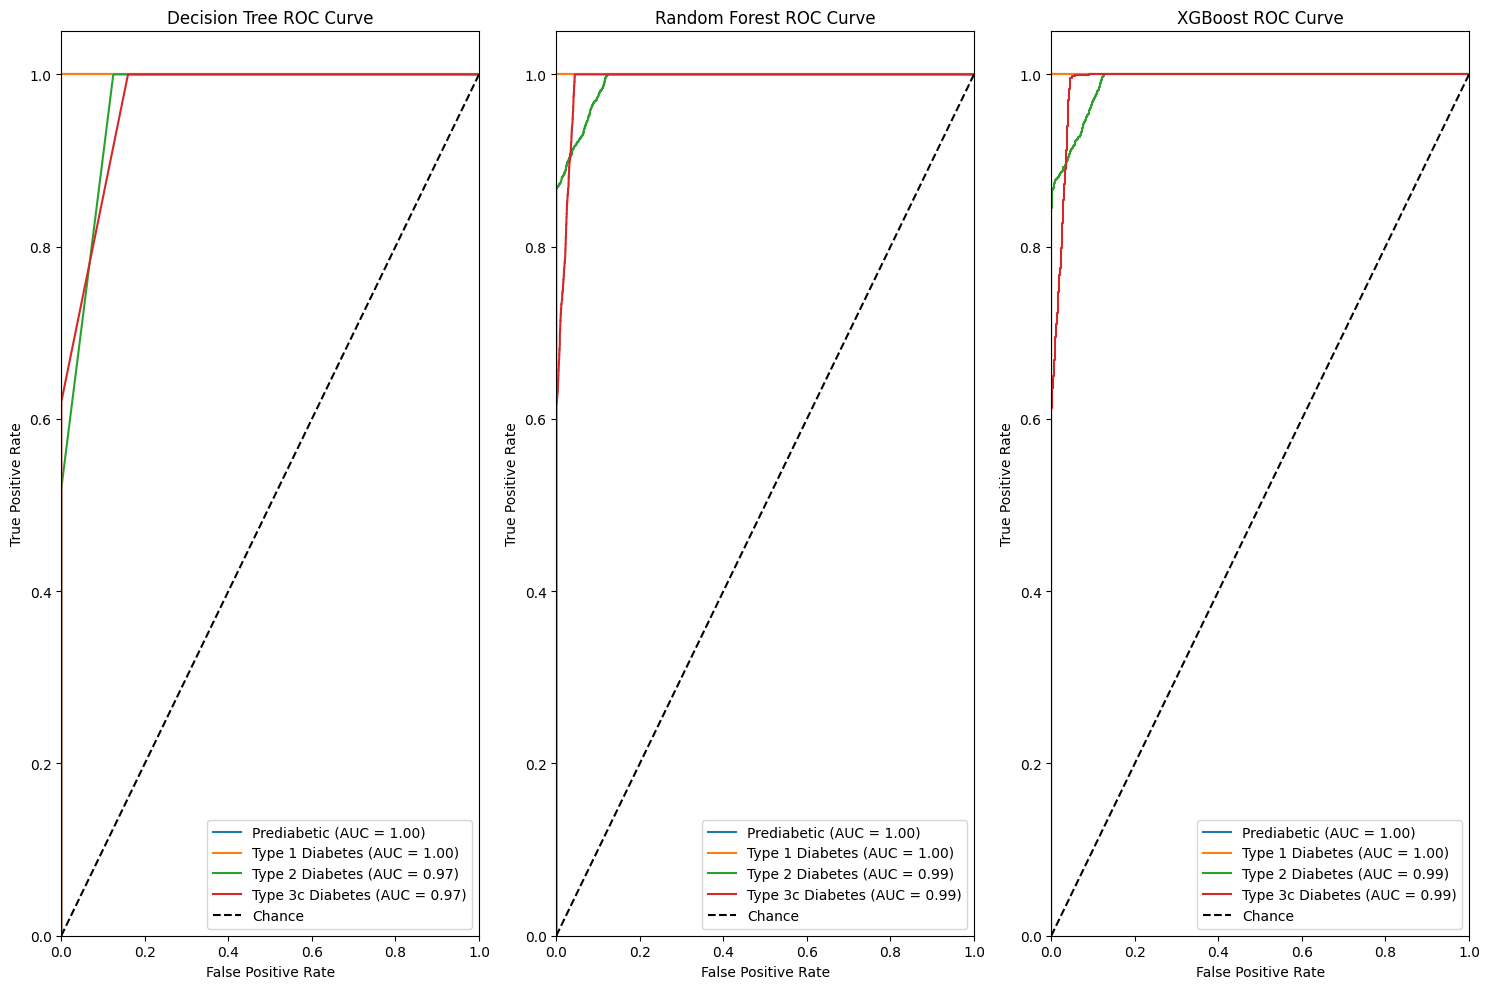

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, brier_score_loss, confusion_matrix
from sklearn.utils import resample
from sklearn.preprocessing import label_binarize

data_path = 'data.csv'
if not os.path.exists(data_path):
    data_path = '../../datasets/data.csv'

print('Loading dataset from:', data_path)
df = pd.read_csv(data_path)

X = df.drop(columns=['Target'])
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f'Resampled train shape after SMOTE: {X_train_res.shape}')

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]
class_names = ['Prediabetic', 'Type 1 Diabetes', 'Type 2 Diabetes', 'Type 3c Diabetes']

dt_params = {
    'max_depth': 6,
    'random_state': 42
}

rf_params = {
    'n_estimators': 96,
    'max_depth': 6,
    'min_samples_split': 100,
    'min_samples_leaf': 80,
    'bootstrap': True,
    'max_features': 'sqrt',
    'criterion': 'entropy',
    'class_weight': 'balanced_subsample',
    'random_state': 42
}

xgb_params = {
    'n_estimators': 96,
    'max_depth': 6,
    'min_child_weight': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'eval_metric': 'mlogloss',
    'random_state': 42
}

models = {
    'Decision Tree': DecisionTreeClassifier(**dt_params),
    'Random Forest': RandomForestClassifier(**rf_params),
    'XGBoost': XGBClassifier(**xgb_params)
}

plt.figure(figsize=(15, 10))

def calculate_specificity(y_true, y_pred, n_classes):
    cm = confusion_matrix(y_true, y_pred)
    specificities = []
    for i in range(n_classes):
        tp = cm[i, i]
        fn = sum(cm[i, :]) - tp
        fp = sum(cm[:, i]) - tp
        tn = sum(sum(cm)) - tp - fn - fp
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(specificity)
    return specificities

def bootstrap_accuracy_ci(model, X_test, y_test, n_iterations=1000):
    stats = []
    for i in range(n_iterations):
        X_res, y_res = resample(X_test, y_test, random_state=i)
        pred = model.predict(X_res)
        acc = np.mean(pred == y_res)
        stats.append(acc)
    lower = np.percentile(stats, 2.5)
    upper = np.percentile(stats, 97.5)
    return lower, upper

def calculate_brier_scores(y_true_bin, y_prob, n_classes):
    brier_scores = []
    for i in range(n_classes):
        score = brier_score_loss(y_true_bin[:, i], y_prob[:, i])
        brier_scores.append(score)
    return brier_scores

plot_idx = 1

for name, model in models.items():
    print('\n' + '='*50)
    print(f'Evaluating Model: {name}')
    print('='*50)

    cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=5, scoring='accuracy')
    print(f'Cross-validation scores: {cv_scores}')
    print(f'Mean CV Accuracy: {np.mean(cv_scores):.4f}')
    print(f'CV Accuracy Std Dev (Fold Variability): {np.std(cv_scores):.4f}')

    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    test_accuracy = np.mean(y_pred == y_test)
    ci_lower, ci_upper = bootstrap_accuracy_ci(model, X_test, y_test)
    print(f'Test Accuracy: {test_accuracy:.4f}')
    print(f'95% Confidence Interval for Test Accuracy: [{ci_lower:.4f}, {ci_upper:.4f}]')

    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    print('\nClassification Report (including Precision, Sensitivity/Recall, F1):')
    print(classification_report(y_test, y_pred, target_names=class_names)) # Print the full report as string

    print('\nSensitivity (Recall) per class:')
    for c_name in class_names:
        sensitivity = report[c_name]['recall']
        print(f'  {c_name}: {sensitivity:.4f}')

    specificities = calculate_specificity(y_test, y_pred, n_classes)
    print('Specificity per class:')
    for c_name, spec in zip(class_names, specificities):
        print(f'  {c_name}: {spec:.4f}')

    macro_roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
    weighted_roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted')
    print(f'\nROC-AUC Score (One-vs-Rest):')
    print(f'  Macro average: {macro_roc_auc:.4f}')
    print(f'  Weighted average: {weighted_roc_auc:.4f}')

    brier_scores = calculate_brier_scores(y_test_bin, y_prob, n_classes)
    print('\nBrier score loss calibration per class (lower is better calibrated):')
    for c_name, b_score in zip(class_names, brier_scores):
        print(f'  {c_name}: {b_score:.4f}')

    plt.subplot(1, 3, plot_idx)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        class_auc = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {class_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} ROC Curve')
    plt.legend(loc='lower right')

    plot_idx += 1

plt.tight_layout()
output_plot = 'roc_curves.png'
plt.savefig(output_plot)
print(f'\nROC Curves plot saved as: {output_plot}')